In [1]:
import json
import os
import time

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from ase import Atoms
import yaml

from fairchem.core.common.tutorial_utils import fairchem_main

import torch
from fairchem.core.datasets import LmdbDataset
from sklearn.metrics import r2_score, mean_absolute_error

/home/enda/miniconda3/envs/MLFFopt_fairchem/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/enda/miniconda3/envs/MLFFopt_fairchem/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def collect_result(dft_path, prd_path, target, application=False):
    '''
    dft_path: input test set (lmdb format).
    prd_path: test prediction output, file name is ocp_predictions.npz 
    target  : target property name in lmdb
    application: Ture if the trained model is used for application.
                 False if it is used to collect output of test result.
    '''
    dft_raw = LmdbDataset({"src": dft_path})
    prd_raw = np.load(prd_path)
    # prd_raw.files

    if not application:
        dft = np.array([data[target] for data in dft_raw])
    
    # get ml result from output
    ids = [int(i.split('_')[1]) for i in prd_raw['ids']]
    inverse_ids = np.argsort(ids)
    prd = np.array([i[0] for i in prd_raw['energy']])
    prd = prd[inverse_ids]
    
    # create pandas dataframe
    dataset = LmdbDataset({"src": dft_path})
    data_list = []
    for ind, data in enumerate(dataset):
        # Customize keys depending on what's in each data sample
        row = {
            "id":     data.id,
            'UUID':   data.UUID,
            target + "_ML" : prd[ind],
        }
        if not application:
            row[target + "_DFT"] = dft[ind]
            # row[target + "_ML" ] = data[target]
            
        data_list.append(row)
    
    # Convert to DataFrame
    df = pd.DataFrame(data_list)
    
    return df

## This notebook contains:
1. A brief explanation of the config file.
2. Train a model of formation enerngy from scratch.
3. Get the performance metric of the trained model.
4. Apply model to predict formation energy of other compounds.

Please copy `set_example_apply` and `set_example_train` obtained by example 1 to this folder.

## 1. A brief explanation of the config yml file.
The config file of this example is `config_Form_scratch.yml`.

### The train/val/test set
The `dataset` section contains the path to the train/val/test lmdb database. `src: set_example_train/train.lmdb` etc.

By `key_mapping: Form: energy`, the target property Form (formation energy) is defined as a global scalar (denoted as energy').

If the data max and min is too large or too small, a normalizer and improve performance. The `mean` and `stdev` can be computed from train dataset.


#### `dataset` section:

``` python
dataset:
  train:
    format: lmdb
    src: set_example_train/train.lmdb
    key_mapping:
      Form: energy
    transforms:
      normalizer:
        energy:
          mean:   0.05
          stdev:  0.40
  val:
    format: lmdb
    src: set_example_train/val.lmdb
    key_mapping:
      Form: energy
  test:
    format: lmdb
    src: set_example_train/test.lmdb
    key_mapping:
      Form: energy
```

#### `model` section
The `model` section defines the model architecture. The example here is an eSEN mdeol of 5 layers with 128 channels. This is simpler than what used for the paper (10 layers, 128 channels), but as an example, this is good and save time.

`num_layers` defines the number of message-passing layers. 

`edge_channels` and `hidden_channels` defines number of channels within  message-passing layers, related to complexity. 

Please read the FairChem document and orignial papers for more details.

```
model:
  backbone:
    act_type: gate
    cutoff: 6.0
    direct_forces: false
    distance_function: gaussian
    edge_channels:    128
    hidden_channels:  128
    lmax: 3
    max_neighbors: 300
    max_num_elements: 100
    mlp_type: spectral
    mmax: 2
    model: esen_backbone
    norm_type: rms_norm_sh
    num_distance_basis: 32
    num_layers: 5
    otf_graph: true
    sphere_channels: 128
    use_envelope: true
    use_pbc: true
    use_pbc_single: true
  heads:
    energy:
      module: esen_mlp_energy_head
  name: hydra
  otf_graph: true
  pass_through_head_outputs: true
```

#### `Optim` section 
The `optim` section defines how model is trained.

`max_epochs` defines the number of epochs. Here, we use 40 for less time cost.

```      
optim:
  batch_size:      32
  eval_batch_size: 32
  # eval_every: 100
  clip_grad_norm: 100
  ema_decay: 0.999
  lr_initial: 0.0004
  max_epochs:  40
  num_workers: 4
  optimizer: AdamW
  optimizer_params:
    weight_decay: 0.001
  scheduler: LambdaLR
  scheduler_params:
    epochs: 40
    lambda_type: cosine
    lr: 0.0004
    lr_min_factor: 0.1
    warmup_epochs: 10
    warmup_factor: 0.2
```

## 2 Train a model of formation energy

### Basic setting
All checkpoints (trained models) and prediction results will be stored in `result_Form`.

The jobname is `Form_scratch`, meaning train a model for formation energy from scratch.

The config yml file is `config_Form_direct.yml`.

The train log and warn message are wirtten to log and warn files.

The `set_example_train` and `set_example_apply` are from the previous example.


In [3]:
run_dir = f"result_Form"   

job_name='Form_scratch'   

config    = f"./config_{job_name}.yml"
log_file  = f"log_train_{job_name}.txt"
warn_file = f"warn_train_{job_name}.txt"


### Train model without GPU

Please remove "--cpu  --optim.num_workers=0" if work with GPU.

The magic `!` is used. The cmd line after `!` is passed to terminal as command line.

In [4]:
# t0 = time.time()
# ! python {fairchem_main()} --mode train --config-yml {config}           \
#                          --run-dir {run_dir}  --identifier {job_name} \
#                          --print-every 50 \
#                          --cpu  --optim.num_workers=0   \
#                          > {log_file} 2>  {warn_file}
# print(f'Elapsed time = {time.time() - t0:1.1f} seconds')

### Train model with GPU

Use GPU number n for train `CUDA_VISIBLE_DEVICES={n}`.

In [5]:
# print GPUs
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")

Device 0: NVIDIA RTX 6000 Ada Generation
Device 1: NVIDIA RTX 6000 Ada Generation
Device 2: Quadro GV100
Device 3: Quadro GV100


In [6]:
t0 = time.time()
! CUDA_VISIBLE_DEVICES={0}  \
python {fairchem_main()} --mode train --config-yml {config}           \
                         --run-dir {run_dir}  --identifier {job_name} \
                         --print-every 50 \
                         > {log_file} 2>  {warn_file}
print(f'Elapsed time = {time.time() - t0:1.1f} seconds')

Elapsed time = 548.3 seconds


## Get the trained model dir

In [7]:
# Obtain output dir for later convenience.
# This dir contains trained model (checkpoint).  
cpline = !grep "checkpoint_dir:" {log_file}
cpdir  = cpline[0].split(':')[-1].strip()
print(cpdir)

result_Form/checkpoints/2025-10-11-11-31-28-Form_scratch


In [8]:
# copy config file to the ouput dir for future need.
! cp {config} {cpdir}'/config.yml'

### Tips
To keep everything in the same notebook, I used the magic `!` to pass cmd to terminal. 

In real work, the cmd to start training can be input to terminal directly or put into a job script.

In [9]:
print('The path to main is:')
print(fairchem_main())

The path to main is:
/home/enda/package/fairchem/src/fairchem/../../main.py


## 3. Collect results of test set. 
Now, we finished the train process and want to check the performance of the model.

Since the prediction of the test is in `npz` format and does not contain True values (DFT values), a function is made to do 
the colloection of the ML and DFT results to a single csv.

This function `collect_result` is defined at the beginning of this notebook and will be used here.

In [10]:
# path to test lmdb set which should be same as the config file.
dft_path = "set_example_train/test.lmdb" 
# path to ML prediction; set automatically here
prd_path = cpdir.replace('checkpoints', 'results')  +'/ocp_predictions.npz'
print('Path to test set used for training: ', dft_path)
print('Path to test prediction by ML: ',      prd_path)

# The ML prediction and True values (DFT values) are collected to df and saved.
# target is the target property, which is the name in lmdb database and should be same as config file.
# application is Flase since we are not using model to predict new compounds.
df = collect_result(dft_path, prd_path, target='Form', application=False)
df.to_csv('./performance_test.csv')


Path to test set used for training:  set_example_train/test.lmdb
Path to test prediction by ML:  result_Form/results/2025-10-11-11-31-28-Form_scratch/ocp_predictions.npz


In [11]:
# the top 4 rows.
df.head(4)

,id,UUID,Form_ML,Form_DFT
0,104575,b7f6a08a-bd24-4652-8e3b-20961ab79991,-0.459229,-0.610177
1,22719,f0af75ff-2bba-4f0d-9c39-bf89e06a050c,0.132324,0.166946
2,104179,8616063a-76ba-4fe4-8c00-d7ef02a6e129,-0.298584,-0.415314
3,5343,744efc0b-d10d-4831-a0eb-1591126a4c34,0.143921,0.174960


#### Make a scatter plot with R2 and MAE
Here a scatter plot is used to understand the performance of the trained model. 
Please note, this is based on test set, not train set.

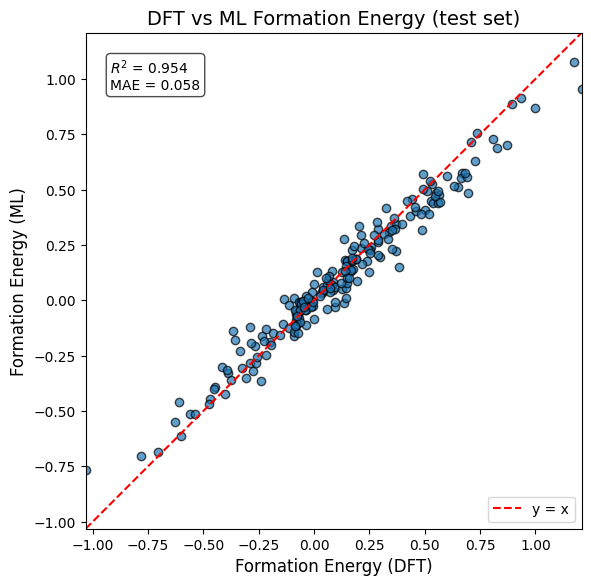

In [13]:
df = pd.read_csv('performance_test.csv', index_col=0)

# Compute metrics
r2 = r2_score(df['Form_DFT'], df['Form_ML'])
mae = mean_absolute_error(df['Form_DFT'], df['Form_ML'])

plt.figure(figsize=(6, 6))

# Scatter plot
plt.scatter(df['Form_DFT'], df['Form_ML'], alpha=0.7, edgecolor='k')

# 1:1 line
lims = [
    min(df['Form_DFT'].min(), df['Form_ML'].min()),
    max(df['Form_DFT'].max(), df['Form_ML'].max())
]
plt.plot(lims, lims, 'r--', label='y = x')

# Labels, title
plt.xlabel("Formation Energy (DFT)", fontsize=12)
plt.ylabel("Formation Energy (ML)", fontsize=12)
plt.title("DFT vs ML Formation Energy (test set)", fontsize=14)

# Same scale for x and y
plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect('equal', adjustable='box')

# Add metrics as text inside plot
plt.text(0.05, 0.95, f"$R^2$ = {r2:.3f}\nMAE = {mae:.3f}",
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

plt.legend()
plt.tight_layout()
plt.savefig('fig_performance.png')
plt.show()


## 4. Application of the trained model
Now, we apply the trained model to predict formation energy of 1000 new compounds. 

Input structures are stored in `set_example_apply/apply.lmdb` which is generated in previous tutorial.

In [14]:
# set path to lmdb of input structures dataset, 
set_apply='set_example_apply/apply.lmdb'

# set path to trained model
# If the application is done seperately, path_model need to be set manually.
path_model = cpdir 
config     = path_model + '/config.yml'
checkpoint = path_model + '/checkpoint.pt'

print('path_model:', path_model)

path_model: result_Form/checkpoints/2025-10-11-11-31-28-Form_scratch


In [15]:
# create the application config file automatically
config_apply     = f"./config_apply.yml"
log_file_apply   = f"log_apply.txt"
warn_file_apply  = f"warn_apply.txt"

! cp {config} {config_apply}

# read config yml file
with open(config_apply) as f:
    config_yml = yaml.safe_load(f)
# change dir to application set
config_yml["dataset"]["test"]["src"] = set_apply
# save back to YAML
with open(config_apply, "w") as f:
    yaml.safe_dump(config_yml, f, sort_keys=False)

Now, use the trained model to do application.

If work without GPU, please modify according to the subsection `train without GPU.`

In [16]:
t0 = time.time()
! CUDA_VISIBLE_DEVICES={2}  \
python {fairchem_main()} --mode predict --config-yml {config_apply}  \
                         --run-dir {run_dir}  --identifier {job_name}'_apply' \
                         --checkpoint {checkpoint}  \
                         > {log_file_apply} 2>  {warn_file_apply}
print(f'Elapsed time = {time.time() - t0:1.1f} seconds')

Elapsed time = 13.3 seconds


In [17]:
# get result dir for collection
cpline = !grep "checkpoint_dir:" {log_file_apply}
cpdir_apply  = cpline[0].split(':')[-1].strip()
print(cpdir_apply)

result_Form/checkpoints/2025-10-11-11-40-00-Form_scratch_apply


Collect result to csv file for easy use and check.

In [18]:
dft_path = set_apply
prd_path = cpdir_apply.replace('checkpoints', 'results')  +'/ocp_predictions.npz'
print('Path to apply lmdb set: ', dft_path)
print('Path to prediction by ML: ',      prd_path)

df = collect_result(dft_path, prd_path, target='Form', application=True)
df.to_csv('result_application.csv')

Path to apply lmdb set:  set_example_apply/apply.lmdb
Path to prediction by ML:  result_Form/results/2025-10-11-11-40-00-Form_scratch_apply/ocp_predictions.npz


In [19]:
# show top 4 rows
df.head(4)

,id,UUID,Form_ML
0,63722,58d62463-5e9a-4294-8828-0445d4f08be0,-0.221680
1,6783,c50bd813-c3f9-4df9-bb62-ce3ea1e79c47,-0.084473
2,4474,af1a22a9-b62f-42a8-a606-feb4cb31e1dc,0.040375
3,56052,c2677a94-e805-4097-b756-3ee133937fe5,-0.282471


Mean:     0.0536
Std Dev:  0.3433
Min:      -0.8662
Max:      1.0166


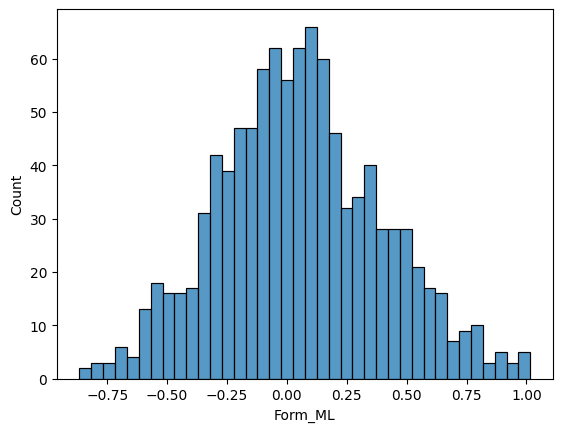

In [20]:
# show distribution
db = df['Form_ML']
sns.histplot(db, binwidth=0.05)

print(f"{'Mean:':<10}{np.mean(db):.4f}")
print(f"{'Std Dev:':<10}{np.std(db):.4f}")
print(f"{'Min:':<10}{np.min(db):.4f}")
print(f"{'Max:':<10}{np.max(db):.4f}")